# Follow-up Analysis: LOX Aging Signals in Thymic Stroma

This notebook characterizes the strongest findings from the LOX expression analysis: mTEC isoform divergence, fibroblast subtype-specific LOX decline, mTEC Lox/Loxl2 co-expression, and a publication-style effect-size bubble plot.

## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from scipy import sparse
from scipy.stats import spearmanr

np.random.seed(0)
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=120, facecolor="white")
sns.set_theme(style="whitegrid", context="paper")

PROJECT_ROOT = Path("..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ADATA_PATH = PROCESSED_DIR / "thymus_annotated.h5ad"
RESULTS_PATH = PROCESSED_DIR / "LOX_differential_results.csv"
LOX_GENES = ["Lox", "Loxl1", "Loxl2", "Loxl3", "Loxl4"]
AGE_KEY = "stage"
YOUNG = "02mo"
OLD = "18mo"
AGE_PALETTE = {YOUNG: "#0072B2", OLD: "#D55E00"}

if not ADATA_PATH.exists():
    raise FileNotFoundError(f"Missing {ADATA_PATH}. Run notebook 04 first.")
if not RESULTS_PATH.exists():
    raise FileNotFoundError(f"Missing {RESULTS_PATH}. Run notebook 05 first.")

adata = sc.read_h5ad(ADATA_PATH)
results = pd.read_csv(RESULTS_PATH)
print(adata)
print(results.head())

AnnData object with n_obs × n_vars = 22877 × 25211
    obs: 'sample', 'stage', 'day', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'ribo_frac', 'hb_frac', 'doublet_score', 'predicted_doublet', 'n_counts', 'leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'leiden_0.8', 'leiden_1.0', 'leiden_1.2', 'leiden_1.4', 'leiden_1.6', 'leiden_1.8', 'leiden_2.0', 'leiden_0.1', 'leiden_0.3', 'leiden_0.5', 'leiden_0.7', 'leiden_0.9', 'cell_type', 'cell_type_subset', 'age_group'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'ribo', 'hb', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'cell_type_subset_colors', 'day_colors', 'hvg', 'leiden'

## 2. Helpers

In [2]:
def expression_vector(adata_like, gene):
    values = adata_like[:, gene].X
    if sparse.issparse(values):
        values = values.toarray()
    return np.asarray(values).ravel()


def add_gene_columns(frame, adata_like, genes):
    out = frame.copy()
    for gene in genes:
        out[gene] = expression_vector(adata_like, gene)
    return out


def log2fc(old_mean, young_mean, pseudocount=1e-9):
    return np.log2((old_mean + pseudocount) / (young_mean + pseudocount))


def mtec_mask(adata_obj):
    return adata_obj.obs["cell_type_subset"].astype(str).str.contains("mTEC", case=False, regex=False)


def fibroblast_mask(adata_obj):
    return adata_obj.obs["cell_type"].astype(str).eq("FB")

## Analysis 1 - mTEC Isoform Divergence

We directly contrast `Lox`, which increased with age in mTECs, against `Loxl2`, which decreased with age.

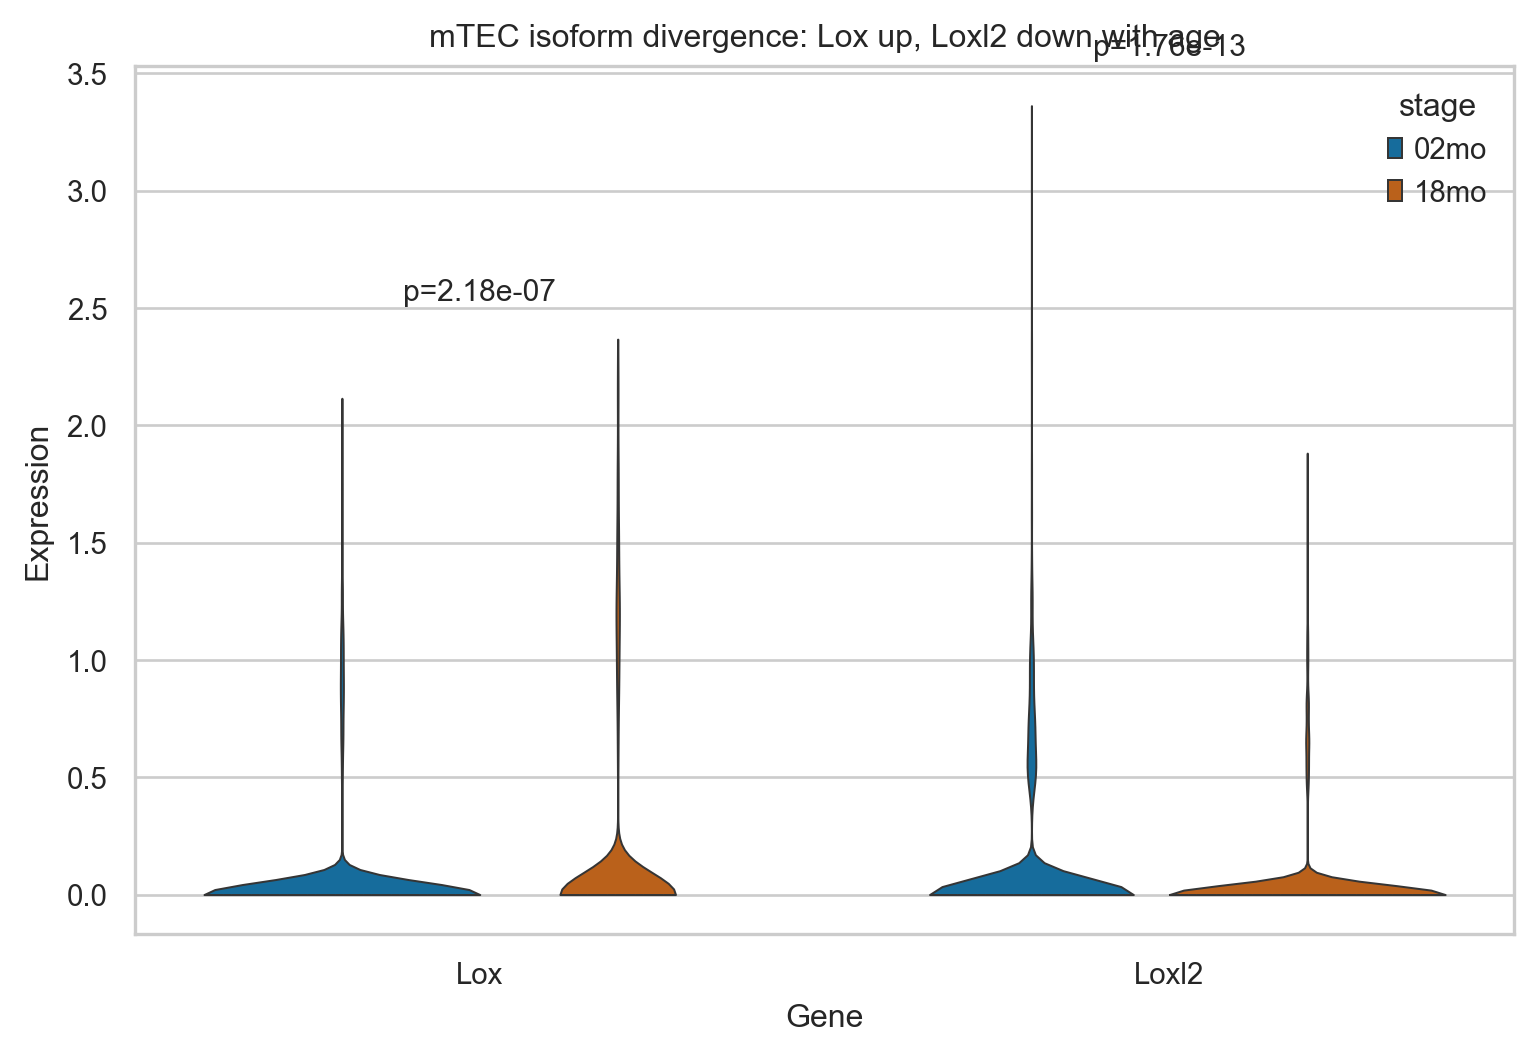

In [3]:
mtec = adata[mtec_mask(adata)].copy()
if mtec.n_obs == 0:
    raise ValueError("No mTEC cells found using cell_type_subset contains 'mTEC'.")

mtec_df = add_gene_columns(mtec.obs[[AGE_KEY, "cell_type_subset"]], mtec, ["Lox", "Loxl2"])
mtec_long = mtec_df.melt(id_vars=[AGE_KEY, "cell_type_subset"], value_vars=["Lox", "Loxl2"], var_name="gene", value_name="expression")

pvals = results[(results["cell_type_analysis"] == "mTEC") & (results["gene"].isin(["Lox", "Loxl2"]))].set_index("gene")["p_value"].to_dict()

plt.figure(figsize=(6.5, 4.5))
ax = sns.violinplot(data=mtec_long, x="gene", y="expression", hue=AGE_KEY, palette=AGE_PALETTE, cut=0, inner="quartile", linewidth=0.6)
for i, gene in enumerate(["Lox", "Loxl2"]):
    p = pvals.get(gene, np.nan)
    ymax = mtec_long.loc[mtec_long["gene"] == gene, "expression"].max()
    ax.text(i, ymax * 1.05 + 0.02, f"p={p:.2e}", ha="center", va="bottom", fontsize=9)
plt.title("mTEC isoform divergence: Lox up, Loxl2 down with age")
plt.xlabel("Gene")
plt.ylabel("Expression")
plt.legend(title=AGE_KEY, frameon=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mTEC_Lox_vs_Loxl2_divergence.png", dpi=300, bbox_inches="tight")
plt.show()

## Analysis 2 - Fibroblast Subtype Breakdown

We split fibroblasts by `cell_type_subset` and quantify which subtype drives the age-associated `Loxl1` decrease. The same table also includes all LOX-family genes so the subtype heatmap can show isoform-specific structure.

Loxl1 subtype breakdown, sorted by strongest decrease:
fibroblast_subtype  gene  n_02mo  n_18mo  mean_02mo  mean_18mo  log2FC_18mo_over_02mo
           4:intFB Loxl1    2691    1880   1.340832   1.035537              -0.372749
             9:Fat Loxl1      29      50   1.163911   0.933320              -0.318536
          3:capsFB Loxl1    2598    1268   1.972504   1.664243              -0.245163
           5:medFB Loxl1    1841    2881   0.219365   0.376809               0.780501


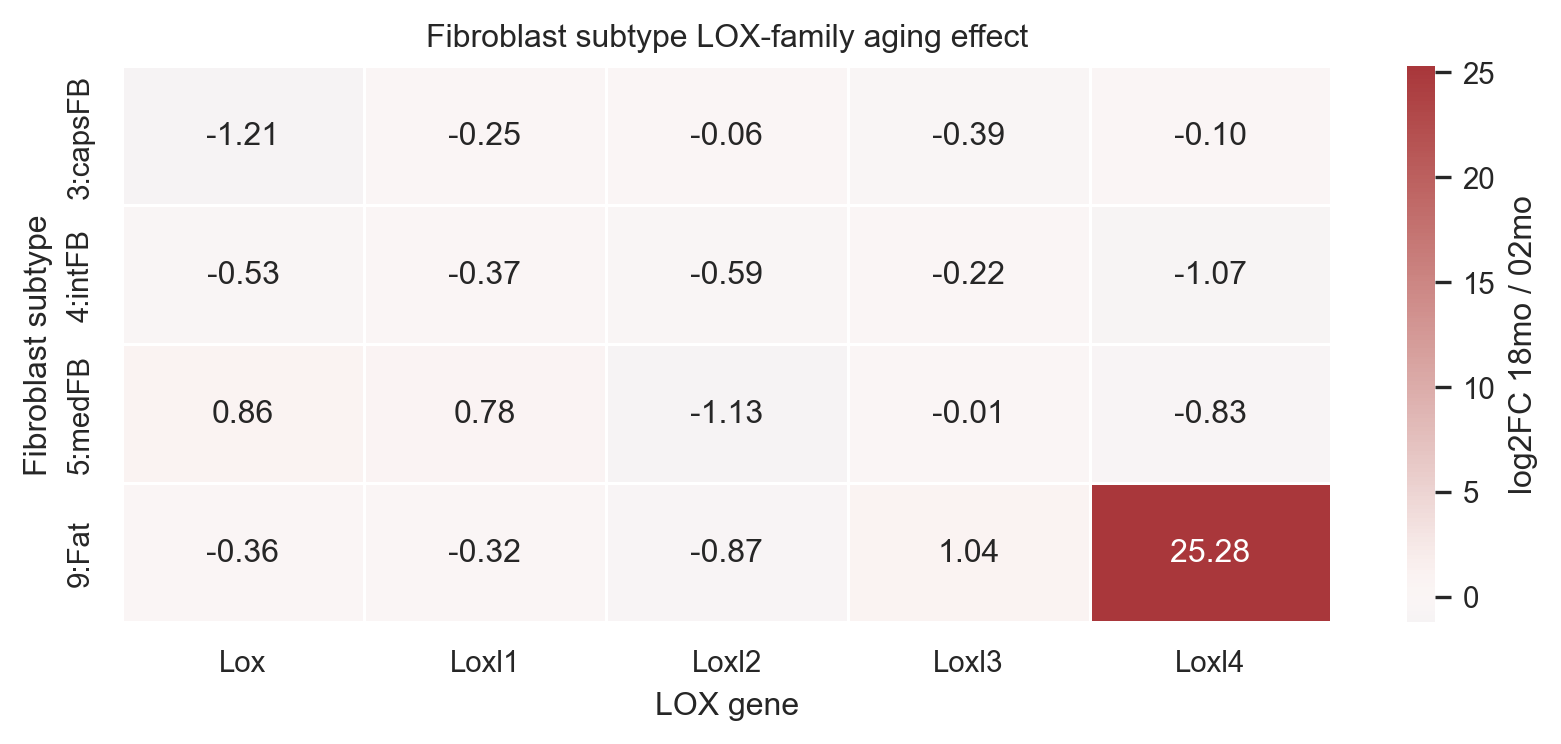

,fibroblast_subtype,gene,n_02mo,n_18mo,mean_02mo,mean_18mo,log2FC_18mo_over_02mo
0,3:capsFB,Lox,2598,1268,0.488693,0.210952,-1.212017
1,3:capsFB,Loxl1,2598,1268,1.972504,1.664243,-0.245163
2,3:capsFB,Loxl2,2598,1268,0.403372,0.387811,-0.056757
3,3:capsFB,Loxl3,2598,1268,0.286616,0.219117,-0.387420
4,3:capsFB,Loxl4,2598,1268,0.009892,0.009242,-0.098003
5,4:intFB,Lox,2691,1880,0.621358,0.429564,-0.532551
6,4:intFB,Loxl1,2691,1880,1.340832,1.035537,-0.372749
7,4:intFB,Loxl2,2691,1880,0.364932,0.242040,-0.592380
8,4:intFB,Loxl3,2691,1880,0.250975,0.215414,-0.220434
9,4:intFB,Loxl4,2691,1880,0.009896,0.004724,-1.066822


In [4]:
fibro = adata[fibroblast_mask(adata)].copy()
if fibro.n_obs == 0:
    raise ValueError("No fibroblasts found using cell_type == 'FB'.")

rows = []
for subtype in sorted(fibro.obs["cell_type_subset"].astype(str).unique()):
    sub = fibro[fibro.obs["cell_type_subset"].astype(str).eq(subtype)].copy()
    for gene in LOX_GENES:
        expr = expression_vector(sub, gene)
        stages = sub.obs[AGE_KEY].astype(str).to_numpy()
        young_expr = expr[stages == YOUNG]
        old_expr = expr[stages == OLD]
        mean_young = float(np.mean(young_expr)) if len(young_expr) else np.nan
        mean_old = float(np.mean(old_expr)) if len(old_expr) else np.nan
        rows.append({
            "fibroblast_subtype": subtype,
            "gene": gene,
            "n_02mo": int(len(young_expr)),
            "n_18mo": int(len(old_expr)),
            "mean_02mo": mean_young,
            "mean_18mo": mean_old,
            "log2FC_18mo_over_02mo": float(log2fc(mean_old, mean_young)) if np.isfinite(mean_young) and np.isfinite(mean_old) else np.nan,
        })

fibro_breakdown = pd.DataFrame(rows)
fibro_breakdown.to_csv(PROCESSED_DIR / "fibroblast_subtype_LOX_breakdown.csv", index=False)

loxl1_breakdown = fibro_breakdown[fibro_breakdown["gene"] == "Loxl1"].sort_values("log2FC_18mo_over_02mo")
print("Loxl1 subtype breakdown, sorted by strongest decrease:")
print(loxl1_breakdown.to_string(index=False))

heatmap_df = fibro_breakdown.pivot(index="fibroblast_subtype", columns="gene", values="log2FC_18mo_over_02mo").loc[:, LOX_GENES]
plt.figure(figsize=(7, max(3.2, 0.45 * len(heatmap_df))))
sns.heatmap(heatmap_df, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.4, cbar_kws={"label": "log2FC 18mo / 02mo"})
plt.title("Fibroblast subtype LOX-family aging effect")
plt.xlabel("LOX gene")
plt.ylabel("Fibroblast subtype")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fibroblast_subtype_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

fibro_breakdown

## Analysis 3 - Co-expression of Lox and Loxl2 in mTECs

This asks whether `Lox` and `Loxl2` are co-expressed in young mTECs but decouple in old mTECs.

stage  n_cells  spearman_rho  p_value
 02mo     1747      0.027646 0.248124
 18mo     1654     -0.058868 0.016647


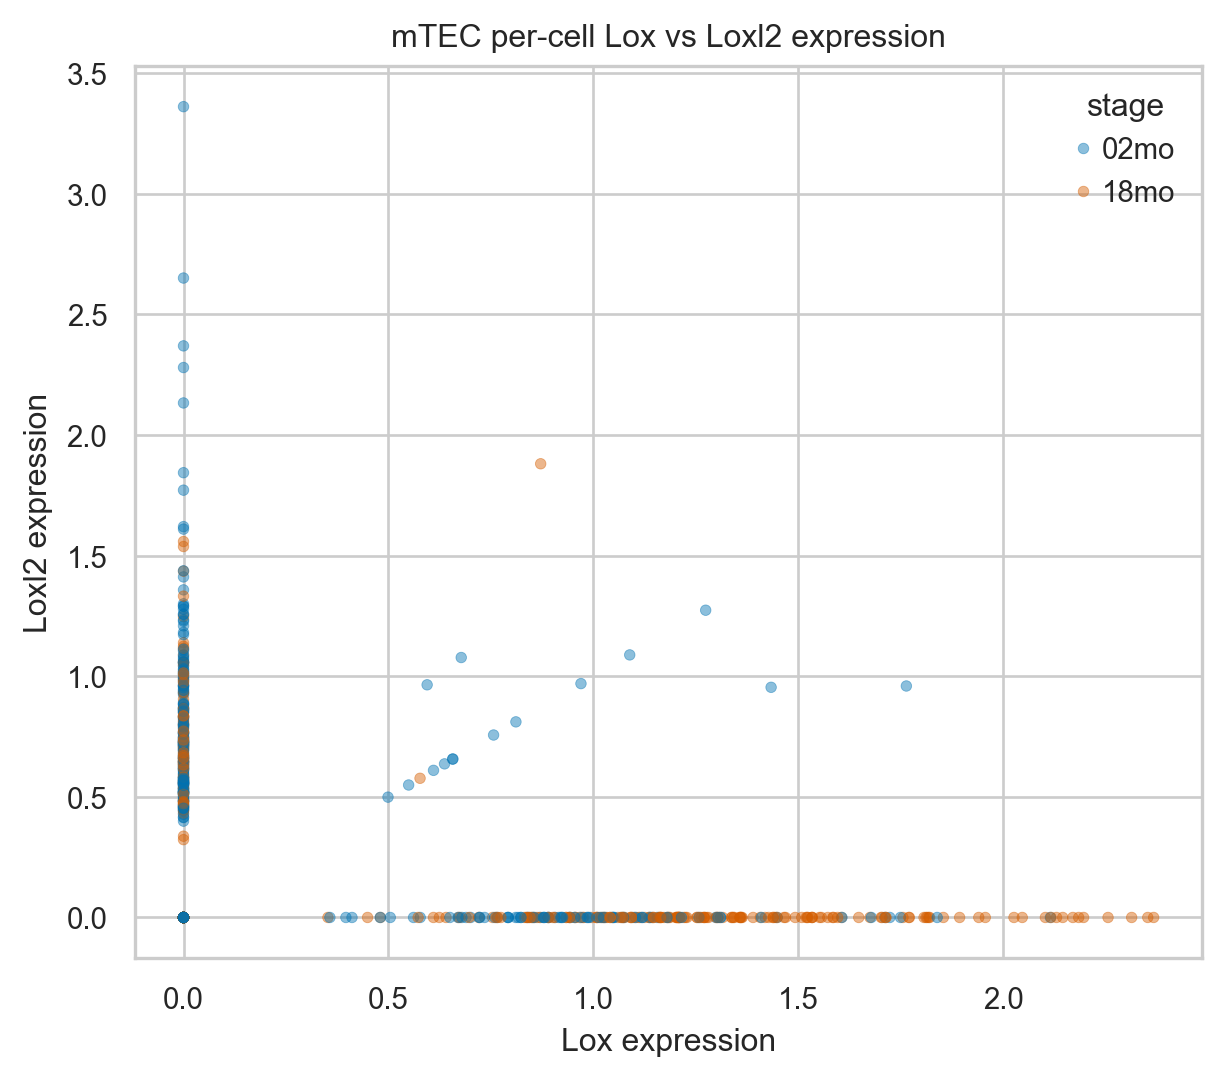

In [5]:
mtec_corr_df = add_gene_columns(mtec.obs[[AGE_KEY, "cell_type_subset"]], mtec, ["Lox", "Loxl2"])
correlation_rows = []
for stage in [YOUNG, OLD]:
    stage_df = mtec_corr_df[mtec_corr_df[AGE_KEY].astype(str) == stage]
    rho, p_value = spearmanr(stage_df["Lox"], stage_df["Loxl2"])
    correlation_rows.append({"stage": stage, "n_cells": len(stage_df), "spearman_rho": rho, "p_value": p_value})

mtec_coexpression = pd.DataFrame(correlation_rows)
mtec_coexpression.to_csv(PROCESSED_DIR / "mTEC_Lox_Loxl2_stage_correlations.csv", index=False)
print(mtec_coexpression.to_string(index=False))

plt.figure(figsize=(5.2, 4.6))
sns.scatterplot(data=mtec_corr_df, x="Lox", y="Loxl2", hue=AGE_KEY, palette=AGE_PALETTE, s=10, alpha=0.45, edgecolor=None)
plt.title("mTEC per-cell Lox vs Loxl2 expression")
plt.xlabel("Lox expression")
plt.ylabel("Loxl2 expression")
plt.legend(title=AGE_KEY, frameon=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mTEC_Lox_Loxl2_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

## Analysis 4 - Effect Size Bubble Plot

This is the main preprint-style summary: x = cell type, y = gene, bubble size = statistical strength, and color = direction/magnitude of age-associated expression change.

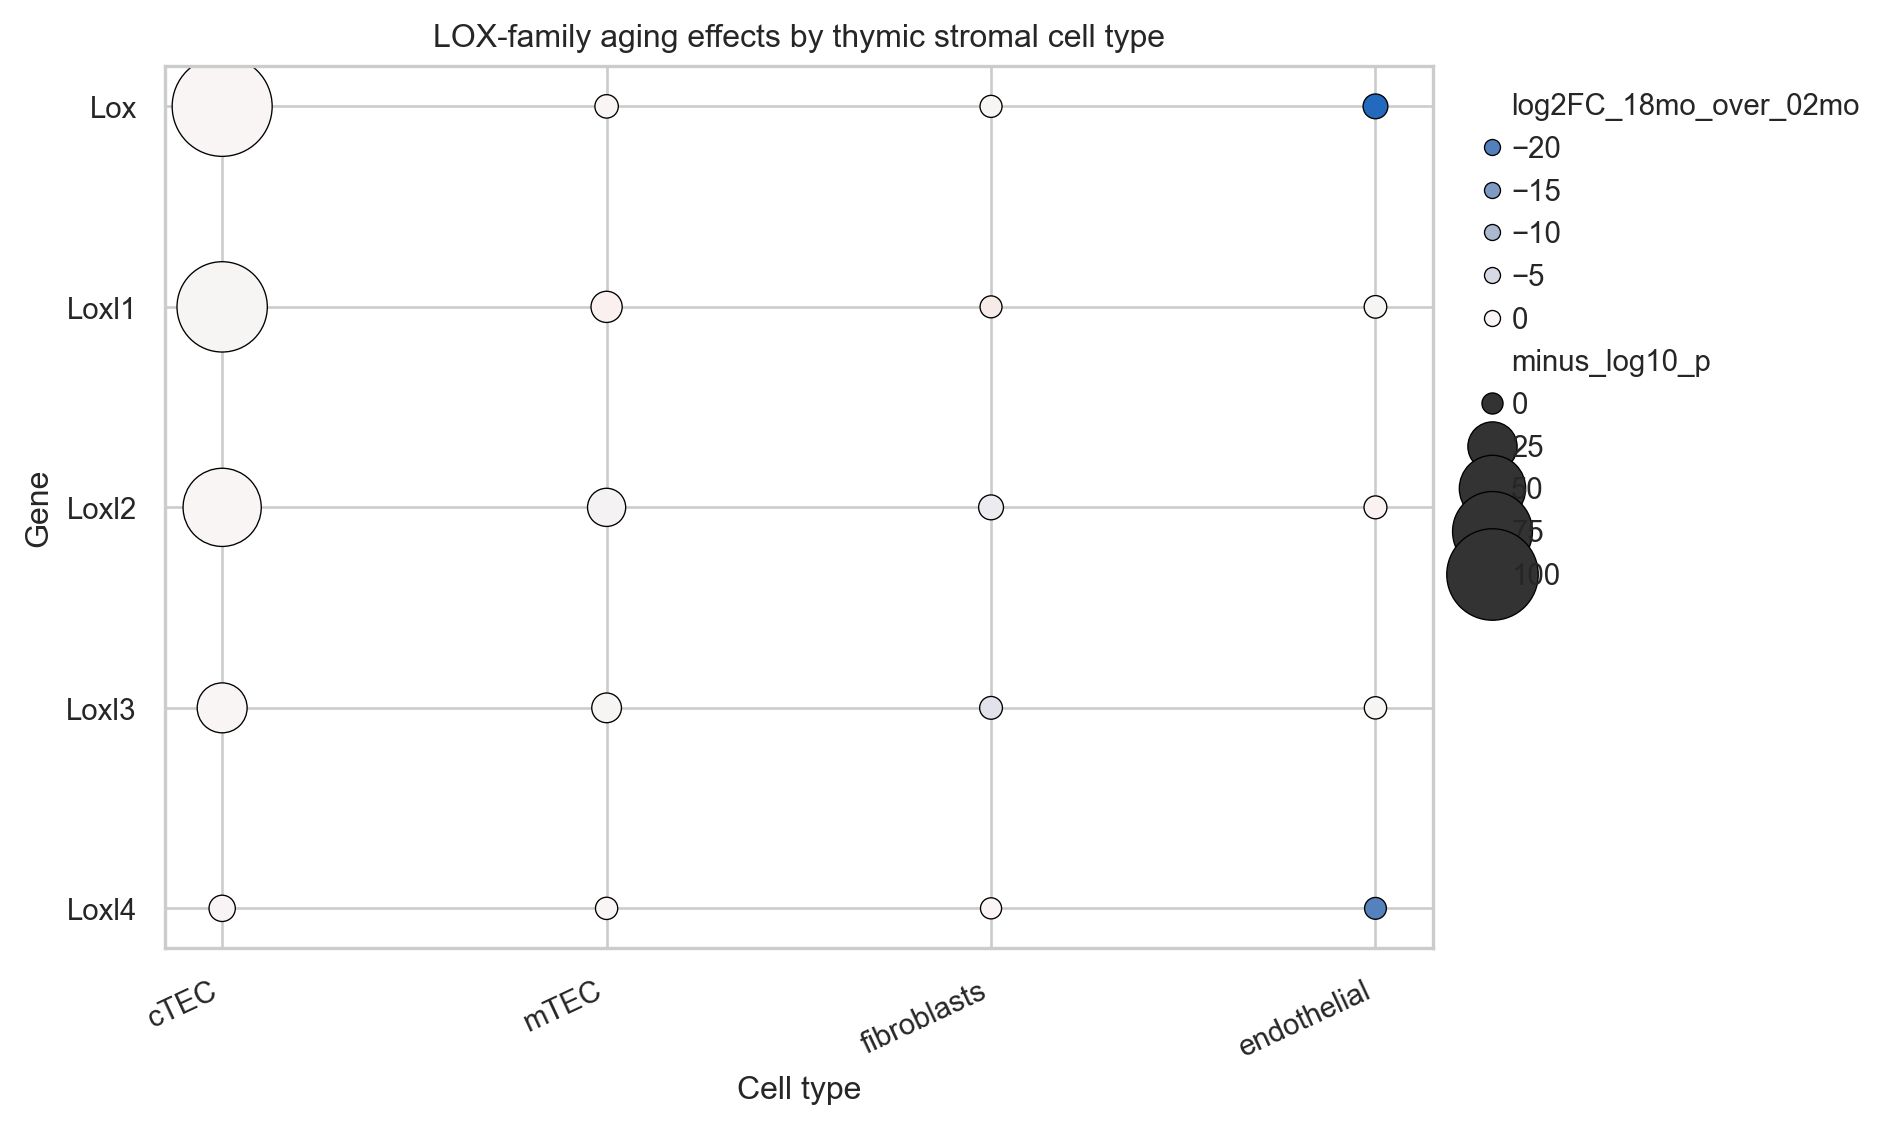

,cell_type_analysis,gene,log2FC_18mo_over_02mo,minus_log10_p,rank_biserial_effect_size_old_vs_young
0,fibroblasts,Loxl1,-0.585506,120.581014,-0.225816
1,fibroblasts,Lox,-0.950324,97.310574,-0.154063
2,fibroblasts,Loxl2,-0.732214,71.495891,-0.130613
3,fibroblasts,Loxl3,-0.357013,25.848751,-0.070313
4,mTEC,Loxl2,-1.345476,12.755112,-0.071235
5,mTEC,Lox,1.259264,6.662393,0.047227
6,mTEC,Loxl3,-0.978439,5.513486,-0.032145
7,fibroblasts,Loxl4,-0.762324,3.114206,-0.004490
8,cTEC,Loxl2,-2.479000,2.194411,-0.053106
9,endothelial,Loxl1,-23.930996,2.142401,-0.010352


In [6]:
bubble = results.copy()
bubble["log2FC_18mo_over_02mo"] = log2fc(bubble["mean_old"], bubble["mean_young"])
bubble["minus_log10_p"] = -np.log10(bubble["p_value"].clip(lower=1e-300))
cell_order = ["cTEC", "mTEC", "fibroblasts", "endothelial"]
gene_order = LOX_GENES

plt.figure(figsize=(8, 4.8))
ax = sns.scatterplot(
    data=bubble,
    x="cell_type_analysis",
    y="gene",
    hue="log2FC_18mo_over_02mo",
    size="minus_log10_p",
    sizes=(40, 900),
    palette="vlag",
    hue_norm=(-max(abs(bubble["log2FC_18mo_over_02mo"].min()), abs(bubble["log2FC_18mo_over_02mo"].max())), max(abs(bubble["log2FC_18mo_over_02mo"].min()), abs(bubble["log2FC_18mo_over_02mo"].max()))),
    edgecolor="black",
    linewidth=0.4,
)
ax.set_xticks(range(len(cell_order)))
ax.set_xticklabels(cell_order, rotation=25, ha="right")
ax.set_yticks(range(len(gene_order)))
ax.set_yticklabels(gene_order)
# Replot through categorical order by setting limits after seaborn's categorical conversion.
plt.title("LOX-family aging effects by thymic stromal cell type")
plt.xlabel("Cell type")
plt.ylabel("Gene")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "Fig2_effect_size_bubbleplot.png", dpi=300, bbox_inches="tight")
plt.show()

bubble[["cell_type_analysis", "gene", "log2FC_18mo_over_02mo", "minus_log10_p", "rank_biserial_effect_size_old_vs_young"]].sort_values("minus_log10_p", ascending=False).head(20)